# import

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../General_Functions/")
from BasicData import *
from Flow_functions import * # import flow functions, Information to the agent
from Geometric_functions import * # Import rotation from euler angles
from Evolution_Traj import * # Import time integration for trjectories
from Time_Int_Traj import * # Import evolution function
from BasicData import *  # Nagents, R0, V
from Strategies import * # Import strategies, Braitenberg or Triangulation
from Strategies_Evolution_MeasureNoise import * # Import strategies Evolution, Braitenberg or Triangulation
from Flow_functions import * # Import flow functions: stokeslet, grads, strains ... 


In [2]:
# Integrate numerically the angular dynamics of each strategy
# Calculate the scalar product between t at the end of the evolution
# and the real source position

    
def EvolutionMeasureNoise(Grad):

    # Function to evaluate the scalar product between t at the end of the evolution
    # and the real source position
    #input:
    # Gradient (source flow measured)
    #output:
    # dot product as a 2D map
    # variance of dot product as 2D map
    
    # Noise intensity
    Intensity = 0.0005*np.linalg.norm(Grad(e3, np.array([2,0,0])))
    
    # t axis for Triangulation strategy absence of roll
    t0_T_not, t1_T_not, t2_T_not = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
    # t axis for Triangulation strategy with roll
    t0_T, t1_T, t2_T = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
    # t axis for Braitenberg strategy with roll
    t0_I, t1_I, t2_I = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
    # t axis for Braitenberg strategy in absence of roll, 4 sensors
    #t0_I_MS, t1_I_MS, t2_I_MS = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
    
    # Resulting dot products
    DotProduct_T_not = np.zeros((NPoints, NPoints, NTrials))
    DotProduct_T = np.zeros((NPoints, NPoints, NTrials))
    DotProduct_I = np.zeros((NPoints, NPoints, NTrials))
    #DotProduct_I_MS = np.zeros((NPoints, NPoints, NTrials))

    for k in range(NPoints):
        for i in range(NPoints):
            AgentPosition =  np.array([z[k], x[i], 0.])
            OptimalDirection = -np.copy(AgentPosition/np.linalg.norm(AgentPosition))

            for trials_i in range(NTrials):
                # Random orientation of agent axis
                alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
                RotationMatrix = Rotation(alpha, np.abs(beta), gamma)

                n_T = np.dot(RotationMatrix,[0, 1, 0])
                b_T = np.dot(RotationMatrix,[0, 0, 1])
                t_T = np.dot(RotationMatrix,[1, 0, 0])

                n_T_not = np.copy(n_T)
                b_T_not = np.copy(b_T)
                t_T_not = np.copy(t_T)

                n_I = np.copy(n_T)
                b_I = np.copy(b_T)
                t_I = np.copy(t_T)

                # Time integration of strategies
                for time in range(Duration):
                    n_T, b_T, t_T = Evolution_Triangulation(n_T, b_T, t_T, AntennaeLength, AgentPosition, Grad, e3, dt, twist, Intensity)
                    n_T_not, b_T_not, t_T_not = Evolution_Triangulation(n_T_not, b_T_not, t_T_not, AntennaeLength, AgentPosition, Grad, e3, dt, 0, Intensity)
                    n_I, b_I, t_I = Evolution_Braitenberg(n_I, b_I, t_I, AntennaeLength, AgentPosition, Grad, e3, dt, twist, Intensity)
                   
                t0_T_not[k, i, trials_i], t1_T_not[k, i, trials_i], t2_T_not[k, i, trials_i] = t_T_not
                t0_T[k, i, trials_i], t1_T[k, i, trials_i], t2_T[k, i, trials_i] = t_T
                t0_I[k, i, trials_i], t1_I[k, i, trials_i], t2_I[k, i, trials_i] = t_I
                #t0_I_MS[k, i, trials_i], t1_I_MS[k, i, trials_i], t2_I_MS[k, i, trials_i] = t_I_MS

                DotProduct_T_not[k, i, trials_i] = np.dot(t_T_not, OptimalDirection)
                DotProduct_T[k, i, trials_i] = np.dot(t_T, OptimalDirection)
                DotProduct_I[k, i, trials_i] = np.dot(t_I, OptimalDirection)
                #DotProduct_I_MS[k, i, trials_i] = np.dot(t_I_MS, OptimalDirection)

    return DotProduct_T, DotProduct_T_not, DotProduct_I,\
        t0_T, t1_T,\
        t0_T_not, t1_T_not,\
        t0_I, t1_I


In [3]:
# Data
NPoints = 60 # Grid number of points per axis
Duration = 255 # Number of timesteps of the numerical integration
NTrials = 10 # Number of trial x point

AntennaeLength = .001 # Sensors distance, on antennae
BodyWidth = .1 # Sensors distance along body
x = np.linspace(0.1, 5.5, NPoints) # x axis
z = np.linspace(0.1, 5.5, NPoints) # z axis

e3 = np.array([1, 0, 0]) # Source flow axis of symmetry, scheme zxy
dt = .1 # Timesteps 
twist = .3 # Roll Intensity

In [6]:
# Calculate and save data

# Information flow 
GradName = ['StrainStokeslet'] # 'GradientStresslet', 'ShearStokeslet', 'GradientStokeslet'
Grads = [StrainStokeslet] # GradientStresslet, ShearStokeslet, GradientStokeslet] 

NameStrategies = ["T_not", "T", "I"] 

for grads_i, Grad in enumerate(Grads):
    # t axis for Triangulation strategy absence of roll
    t0_T_not, t1_T_not = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
    t0_T, t1_T = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
    t0_I, t1_I = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
    # t0_I_MS, t1_I_MS = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))

    # Evaluate the strategy 2D map, vector P 
    Avg_P_T_not = np.zeros((NPoints, NPoints, NTrials))
    Avg_P_T = np.zeros((NPoints, NPoints, NTrials))
    Avg_P_I = np.zeros((NPoints, NPoints, NTrials))
    # Avg_P_I_MS = np.zeros((NPoints, NPoints, NTrials))

    Avg_P_T, Avg_P_T_not, Avg_P_I, t0_T, t1_T, t0_T_not, t1_T_not, t0_I, t1_I = EvolutionMeasureNoise(Grad)
    # Set up figure and image grid

    AllAvg = [Avg_P_T_not, Avg_P_T, Avg_P_I]
    Allt0 = [t0_T_not, t0_T, t0_I]
    Allt1 = [t1_T_not, t1_T, t1_I]

    for i, strat_name in enumerate(NameStrategies):
        np.savetxt("Data_MeasureNoise/"+str(GradName[grads_i])+"_Avg_"+str(strat_name)+".txt", np.mean(AllAvg[i], axis = 2), delimiter = ',')
        np.savetxt("Data_MeasureNoise/"+str(GradName[grads_i])+"_t0_"+str(strat_name)+".txt", np.mean(Allt0[i], axis = 2), delimiter = ',')
        np.savetxt("Data_MeasureNoise/"+str(GradName[grads_i])+"_t1_"+str(strat_name)+".txt", np.mean(Allt1[i], axis = 2), delimiter = ',')

#plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


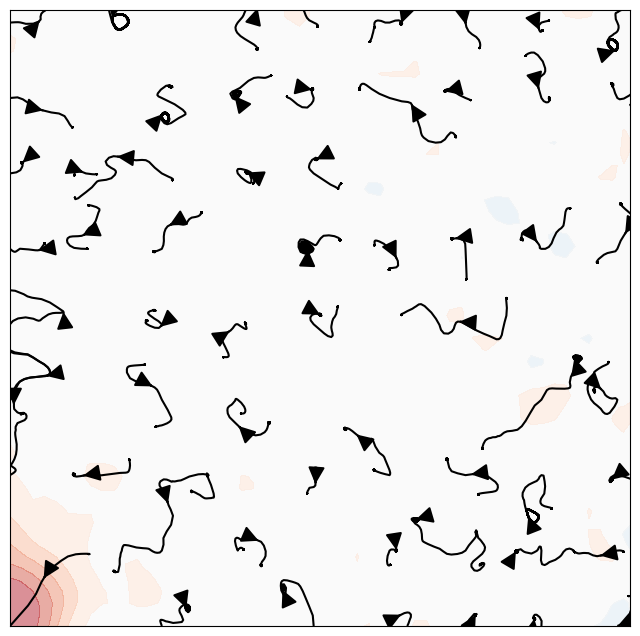

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


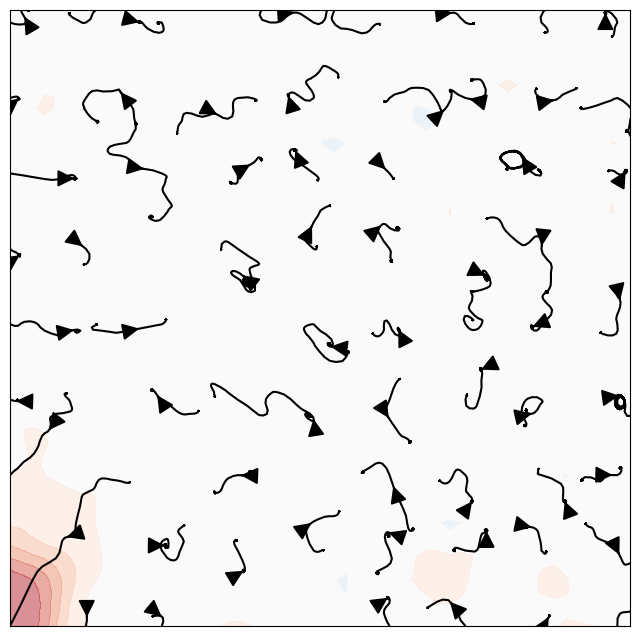

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


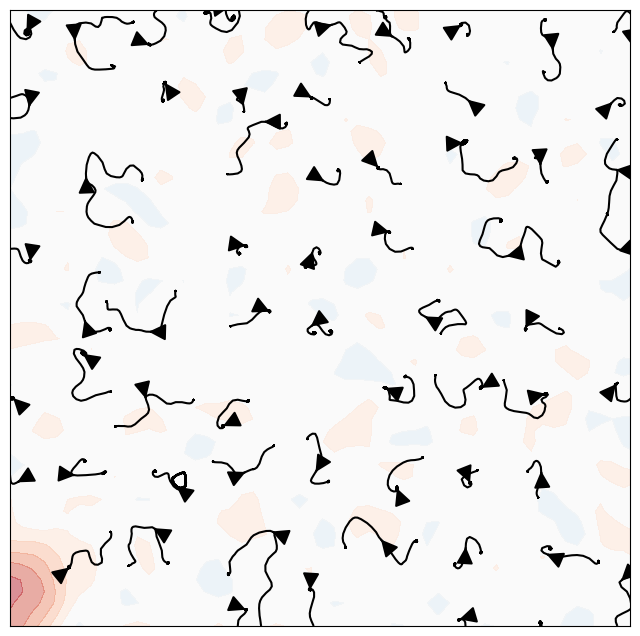

In [7]:
# Plot data from Save 

import scipy.ndimage as ndimage # import to smooth plots

for grads_i, Grad in enumerate(GradName):
    for i, strat_name in enumerate(NameStrategies):
        
        # Extract data from saved file
        with open("Data_MeasureNoise/"+str(GradName[grads_i])+"_Avg_"+str(strat_name)+".txt", 'r') as the_file:
            Avg = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 


        with open("Data_MeasureNoise/"+str(GradName[grads_i])+"_t0_"+str(strat_name)+".txt", 'r') as the_file:

            t0 = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 
        with open("Data_MeasureNoise/"+str(GradName[grads_i])+"_t1_"+str(strat_name)+".txt", 'r') as the_file:

            t1 = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 

        # Plot parameters
        CMAP = 'RdBu_r' #'spring'
        STREAMCOLOR = 'black'

        fig1, axs = plt.subplots(nrows=1, ncols=1, figsize=(8,8), sharex='col', sharey='row')
        ax1 = axs
        X, Z = np.meshgrid(x, z, indexing='xy')

        # Add data to image grid
        levels = np.linspace(-1, 1.00001, 14)

        Avg = ndimage.gaussian_filter(Avg, sigma=1.0, order=0)
        im = ax1.contourf(X, Z, Avg, cmap = CMAP, levels = levels, vmin= -1, vmax = 1, alpha = 0.5)
        ax1.streamplot(X, Z, t1, t0, color = STREAMCOLOR,  density = .35,  arrowsize = 2.5, broken_streamlines=False)
        #PlotCircles(ax1, .5)
        ax1.set_xlim([.1, 5])
        ax1.set_ylim([.1, 5])
        ax1.set_xticks([])
        ax1.set_yticks([])



        # plt.colorbar(im, ax = axs, ticks = np.arange(-1, 1.1, 0.5), location= 'bottom')
        # Uncomment to save
        plt.savefig("Plots_MeasureNoise/"+str(GradName[grads_i])+"_"+str(strat_name)+".eps", format = 'eps', bbox_inches='tight')
        plt.savefig("Plots_MeasureNoise/"+str(GradName[grads_i])+"_"+str(strat_name)+".pdf", bbox_inches='tight')
        plt.show()